# EpiCoV EDA for Jan-Apr 2020

- Number of sequences: `98291`
- Collection date range: 1 Jan 2020 to 15 Apr 2020 (14 weeks data)
- Submission date range: 11 Jan 2020 to 17 Apr 2025

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Geospatial libraries
import pycountry # to standardize country names
import difflib # to get close matches for country names
import pycountry_convert as pc # to convert country names to ISO codes

import warnings
warnings.filterwarnings("ignore")

In [2]:
%%time
FILEPATH = "../data/1Jan20_15Apr20_collected.csv"
params = {"filepath_or_buffer":FILEPATH, "sep": "," if FILEPATH.endswith(".csv") else "\t"}
df = pd.read_csv(**params)
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98291 entries, 0 to 98290
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Accession ID                     98291 non-null  object
 1   Submission date                  98291 non-null  object
 2   Virus name                       98291 non-null  object
 3   Collection date                  98291 non-null  object
 4   Location                         98291 non-null  object
 5   Host                             98291 non-null  object
 6   Additional location information  3591 non-null   object
 7   Sampling strategy                4748 non-null   object
 8   Gender                           98291 non-null  object
 9   Patient age                      98288 non-null  object
 10  Patient status                   98276 non-null  object
 11  Last vaccinated                  45 non-null     object
 12  Passage                         

((98291, 18), None)

In [3]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2020-01-11 00:00:00'), Timestamp('2025-04-17 00:00:00'))

In [4]:
df["submission_month_yr"] = df["Submission date"].dt.strftime("%Y-%m")
df["submission_month_yr"].value_counts().sort_index()

submission_month_yr
2020-01       51
2020-02      168
2020-03     2922
2020-04    12300
2020-05    15801
2020-06     9991
2020-07     7126
2020-08     4668
2020-09     5134
2020-10     6146
2020-11     3095
2020-12     4032
2021-01     5204
2021-02     2797
2021-03     2155
2021-04     1638
2021-05      630
2021-06     2448
2021-07     1448
2021-08      701
2021-09      572
2021-10     1065
2021-11      498
2021-12      367
2022-01      539
2022-02       86
2022-03      769
2022-04      684
2022-05      223
2022-06      165
2022-07      138
2022-08      866
2022-09      468
2022-10      411
2022-11      429
2022-12       28
2023-01       11
2023-02       29
2023-03       73
2023-04       98
2023-05       24
2023-06      145
2023-07      468
2023-08       26
2023-09      155
2023-10      120
2023-11      293
2023-12      277
2024-01        4
2024-02        5
2024-03      170
2024-04      223
2024-05       24
2024-07        2
2024-08       12
2024-10      188
2024-11       12
2024-12    

In [5]:
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")
df["Collection date"].min(), df["Collection date"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2020-04-15 00:00:00'))

In [6]:
df["collection_month_yr"] = df["Collection date"].dt.strftime("%Y-%m")
df["collection_month_yr"].value_counts().sort_index()

collection_month_yr
2020-01      947
2020-02     2255
2020-03    58574
2020-04    36515
Name: count, dtype: int64

Let us validate if `Submission_date` is after the `Collection_date`

In [7]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 20)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [8]:
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

count    98291.000000
mean       226.549013
std        272.157742
min          0.000000
25%         49.000000
50%        133.000000
75%        295.000000
max       1857.000000
Name: collection_to_submission_days, dtype: float64

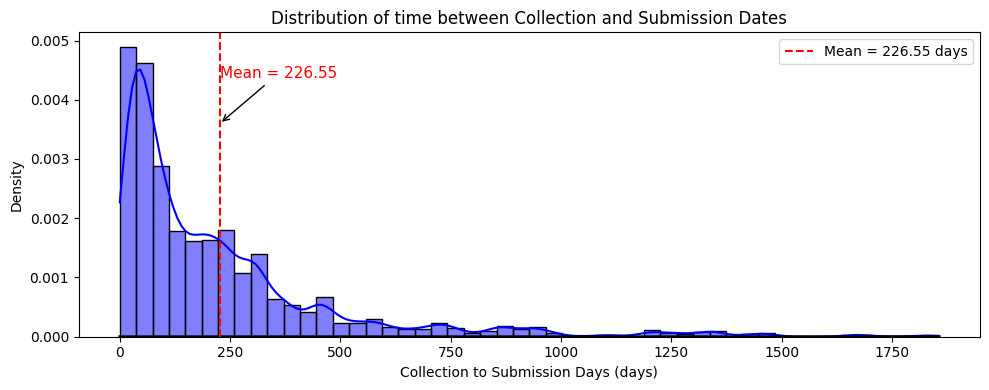

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title("Distribution of time between Collection and Submission Dates")
plt.legend()
plt.tight_layout()
plt.savefig("epicov2020_plots/collection_to_submission_days_distribution1.png", dpi=300)
plt.show()

In [10]:
(pd.to_datetime("2020-11-07") - pd.to_datetime("2020-03-26")).days

226

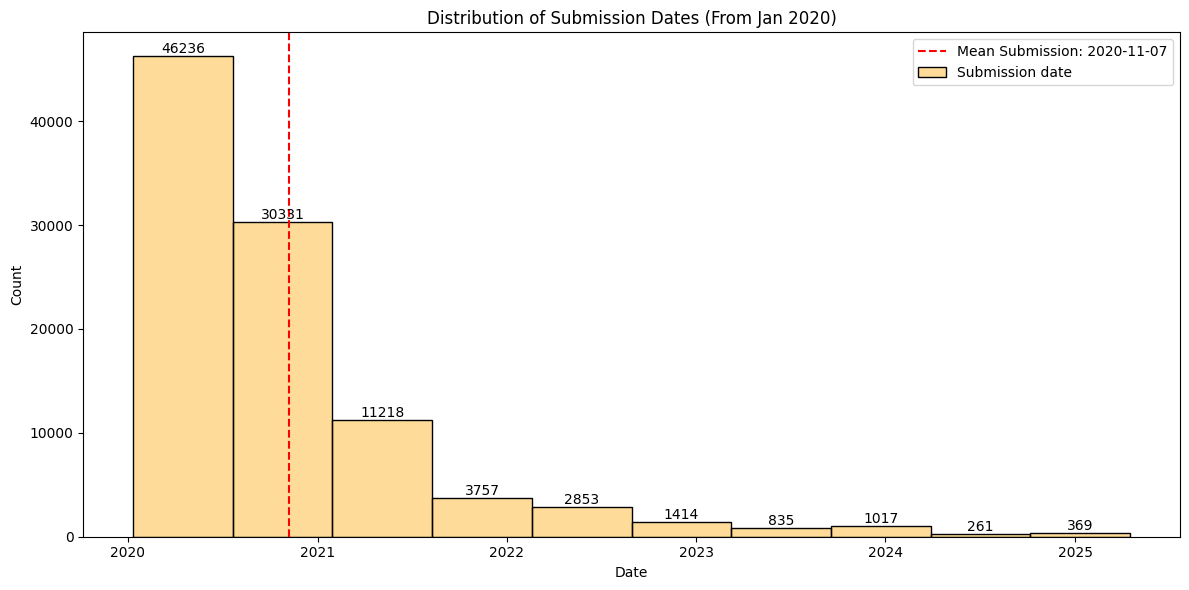

In [11]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Distribution of Submission Dates (From Jan 2020)")
plt.legend()
plt.tight_layout()
plt.savefig("epicov2020_plots/submission_dates_spread.png", dpi=300)
plt.show()

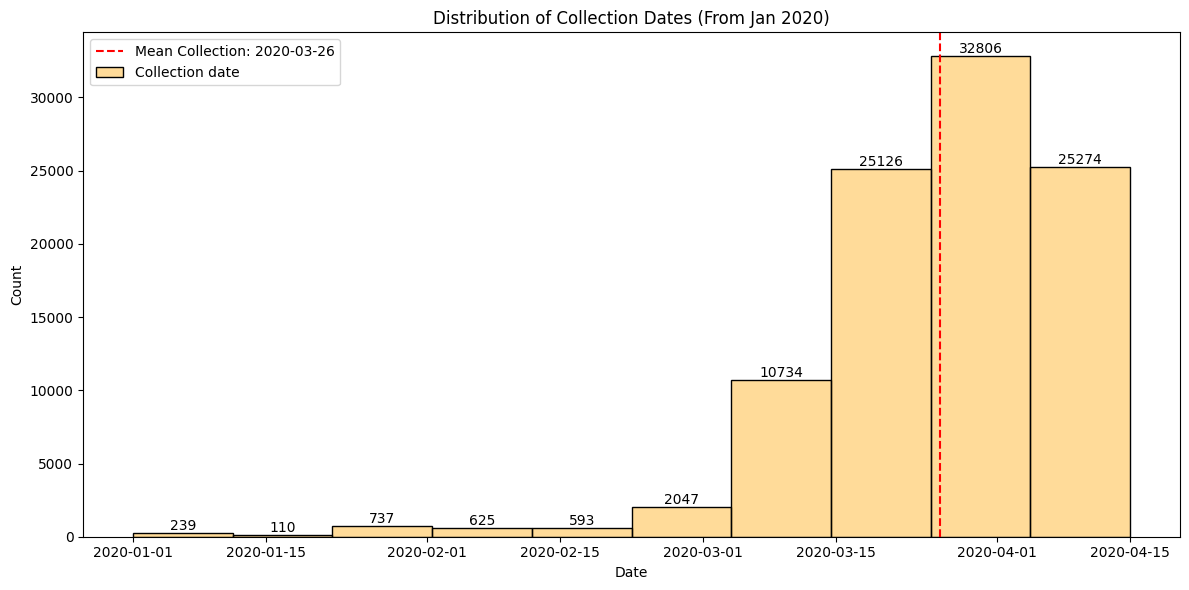

In [12]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Distribution of Collection Dates (From Jan 2020)")
plt.legend()
plt.tight_layout()
plt.savefig("epicov2020_plots/collection_dates_spread.png", dpi=300)
plt.show()

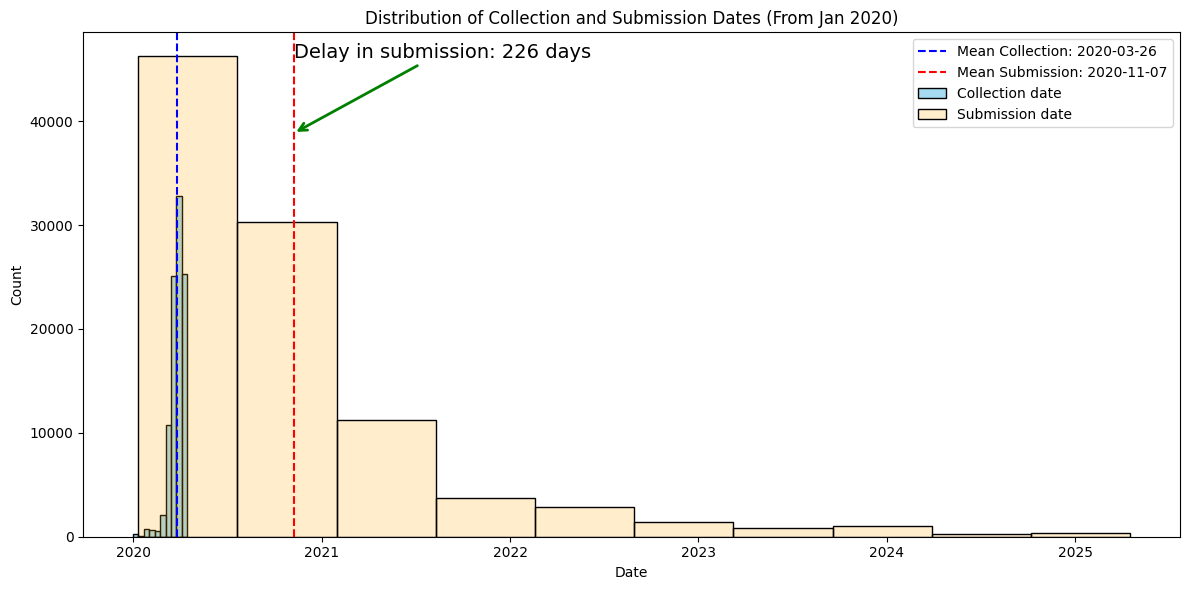

In [13]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Distribution of Collection and Submission Dates (From Jan 2020)")
plt.legend()
plt.tight_layout()
plt.savefig("epicov2020_plots/collection_submission_dates_distribution1.png", dpi=300)
plt.show()

## Geographical distribution

Let's see the geographical distribution of various parameters

In [14]:
set([x.split("/")[0] for x in df["Location"].values.tolist()])

{'Africa ', 'Asia ', 'Europe ', 'North America ', 'Oceania ', 'South America '}

In [15]:
df.nunique()

Accession ID                       98291
Submission date                      833
Virus name                         98269
Collection date                      104
Location                            2823
Host                                   1
Additional location information      574
Sampling strategy                     77
Gender                                13
Patient age                          249
Patient status                        98
Last vaccinated                        6
Passage                               78
Specimen                             231
Additional host information          223
Lineage                              571
Clade                                 11
AA Substitutions                   29400
submission_month_yr                   60
collection_month_yr                    4
collection_to_submission_days       1405
dtype: int64

Collate required columns

In [16]:
df1 = df[["Accession ID", "Location", "Gender", "Patient age", "Patient status"]]
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98291 entries, 0 to 98290
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    98291 non-null  object
 1   Location        98291 non-null  object
 2   Gender          98291 non-null  object
 3   Patient age     98288 non-null  object
 4   Patient status  98276 non-null  object
dtypes: object(5)
memory usage: 3.7+ MB


Split location into `continent`, `country`, `state` and `city`

In [17]:
df1["continent"], df1["country"], df1["state"], df1["city"] = np.nan, np.nan, np.nan, np.nan

cols = ["continent", "country", "state", "city"]
for i, row in tqdm(df1.iterrows(), desc="Geographical information extraction", total=df1.shape[0]):
    loc = row["Location"]
    locs = [x.strip() for x in loc.split("/")]
    for j in range(min(len(locs),len(cols))):
        df1.loc[i, cols[j]] = locs[j]
df1.drop(columns=["Location"], inplace=True)
df1.info()

Geographical information extraction: 100%|██████████| 98291/98291 [00:26<00:00, 3647.53it/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98291 entries, 0 to 98290
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    98291 non-null  object
 1   Gender          98291 non-null  object
 2   Patient age     98288 non-null  object
 3   Patient status  98276 non-null  object
 4   continent       98291 non-null  object
 5   country         98291 non-null  object
 6   state           89063 non-null  object
 7   city            21454 non-null  object
dtypes: object(8)
memory usage: 6.0+ MB


## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata

In [18]:
df1["country"].nunique(), df1["country"].unique()

(145,
 array(['Germany', 'France', 'Qatar', 'Oman', 'Brazil', 'Australia',
        'Belgium', 'USA', 'Portugal', 'Serbia', 'Israel', 'Switzerland',
        'South Korea', 'Japan', 'Netherlands', 'Canada', 'Peru', 'Austria',
        'United Kingdom', 'Iceland', 'Spain', 'Ireland', 'Italy',
        'Thailand', 'Malaysia', 'Hong Kong', 'Singapore', 'Finland',
        'Denmark', 'Iran', 'Slovenia', 'Norway', 'Sweden', 'Luxembourg',
        'Taiwan', 'Greece', 'Saudi Arabia', 'Guadeloupe', 'Chile',
        'United Arab Emirates', 'Faroe Islands', 'Mexico', 'New Zealand',
        'Costa Rica', 'Czech Republic', 'Panama', 'Bahrain', 'Russia',
        'Georgia', 'Philippines', 'Bangladesh', 'Curacao', 'Aruba',
        'Lebanon', 'China', 'Gabon', 'Senegal', 'Vietnam', 'French Guiana',
        'Morocco', 'Colombia', 'India', 'South Africa', 'Egypt',
        'Cambodia', 'Indonesia', 'Hungary', 'Venezuela',
        'Democratic Republic of the Congo', 'Argentina', 'Bolivia',
        'Moldova', 'Sa

Countrywise population from [Our World in Data](https://ourworldindata.org/population-growth)

In [19]:
df_pop = pd.read_csv("../data/our_world_in_data_population.csv")
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 75 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  256 non-null    object
 1   1950     256 non-null    int64 
 2   1951     256 non-null    int64 
 3   1952     256 non-null    int64 
 4   1953     256 non-null    int64 
 5   1954     256 non-null    int64 
 6   1955     256 non-null    int64 
 7   1956     256 non-null    int64 
 8   1957     256 non-null    int64 
 9   1958     256 non-null    int64 
 10  1959     256 non-null    int64 
 11  1960     256 non-null    int64 
 12  1961     256 non-null    int64 
 13  1962     256 non-null    int64 
 14  1963     256 non-null    int64 
 15  1964     256 non-null    int64 
 16  1965     256 non-null    int64 
 17  1966     256 non-null    int64 
 18  1967     256 non-null    int64 
 19  1968     256 non-null    int64 
 20  1969     256 non-null    int64 
 21  1970     256 non-null    int64 
 22  19

In [20]:
(len(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(9,
 {'Canary Islands',
  'Crimea',
  'Czech Republic',
  'Democratic Republic of the Congo',
  'Saint Martin',
  'The Bahamas',
  'Timor-Leste',
  'U.S. Virgin Islands',
  'USA'})

In [21]:
# Precompute country name variants
country_names = set()
name_map = {}

for country in pycountry.countries:
    variants = {country.name}
    if hasattr(country, 'official_name'):
        variants.add(country.official_name)
    if hasattr(country, 'common_name'):
        variants.add(country.common_name)
    
    for variant in variants:
        lower_variant = variant.lower()
        country_names.add(lower_variant)
        name_map[lower_variant] = country.name  # map to standard name

def standardize_country_name(name):
    name_lower = name
    if isinstance(name, str):
        name_lower = name.strip().lower()

        # Try direct lookup
        try:
            return pycountry.countries.lookup(name).name
        except LookupError:
            # Fallback: fuzzy match
            closest = difflib.get_close_matches(name_lower, country_names, n=1, cutoff=0.8)
            if closest:
                return name_map[closest[0]]
            return name  # Return original if no close match
    return name  # Return as is if not a string

In [22]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)]["country"].value_counts()

country
USA                                 26333
Czech Republic                        212
Democratic Republic of the Congo      110
Canary Islands                         81
Timor-Leste                            17
U.S. Virgin Islands                    11
Saint Martin                           10
The Bahamas                             2
Crimea                                  1
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet.

In [23]:
[x for x in df_pop["country"] if "Bah" in x]

['Bahamas', 'Bahrain']

In [24]:
df1["country"] = df1["country"].str.replace("USA", "United States")
df1["country"] = df1["country"].str.replace("Democratic Republic of the Congo", "Democratic Republic of Congo")
df1["country"] = df1["country"].str.replace("Timor-Leste", "East Timor")

In [25]:
df_pop["country"] = df_pop["country"].str.replace("Czechia", "Czech Republic")
df_pop["country"] = df_pop["country"].str.replace("United States Virgin Islands", "U.S. Virgin Islands")
df_pop["country"] = df_pop["country"].str.replace("Saint Martin (French part)", "Saint Martin")
df_pop["country"] = df_pop["country"].str.replace("Bahamas", "The Bahamas")

In [26]:
countries = df1["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(145, [{'country': 'Germany'}, {'country': 'France'}, {'country': 'Qatar'}])

In [27]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)].shape[0], df1[df1["country"].isin(focus)]["country"].value_counts()

(82,
 country
 Canary Islands    81
 Crimea             1
 Name: count, dtype: int64)

Population of Canary Islands is part of that of Spain - how to deal?

In [28]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df1[df1["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country]["2020"].values[0]
        x["population"] = int(pop)
    elif country in ["Canary Islands","Crimea"]:
        x["population"] = float("NaN")
country_meta[:3]

Filling population data: 100%|██████████| 145/145 [00:00<00:00, 148.44it/s]


[{'country': 'Germany', 'continent': 'Europe', 'population': 83628661},
 {'country': 'France', 'continent': 'Europe', 'population': 65905226},
 {'country': 'Qatar', 'continent': 'Asia', 'population': 2803329}]

Collect only entries where population is non-zero => exclude Canary Islands as of now

In [29]:
df2 = df1[df1["country"]!="Canary Islands"]
df1.shape, df2.shape

((98291, 8), (98210, 8))

In [30]:
def choropleth_world(df, value_column, color_scale="balance", title=None, hover_data=None, label=None):
    """Plot a choropleth map of the world using Plotly Express.

    Args:
        df (pd.DataFrame): DataFrame containing country data.
        value_column (str): Column name in the DataFrame to plot on the map.
        color_scale (Union[str, dict], optional): The color map to use. If custom one define it as a dict, else use str. Defaults to "balance".
        title (str, optional): Plot title. Defaults to None.
        hover_data (dict, optional): Boolean dict showing which columns of the dataframe to show on hovering over the country. Defaults to None.
        label (str, optional): Colorbar title. Defaults to None.
    """
    col_to_plot = value_column + "_filled"
    
    hover = hover_data if hover_data else {k: True for k in df.columns}
    
    # Replace NaNs with a sentinel value (e.g., -1)
    df[col_to_plot] = df[value_column].fillna(-1)

    fig = px.choropleth(
            df,
            locations='country',
            locationmode='country names',
            color=col_to_plot,
            color_continuous_scale=color_scale,
            title=title,
            labels={col_to_plot: label},
            hover_name='country',
            hover_data=hover,
            projection='natural earth',
            range_color=[df[col_to_plot].min(), df[col_to_plot].max()]  # Correct usage
        )

    fig.update_geos(showframe=True, showcoastlines=True)
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title_x=0.5, width=1200)

    # Rename colorbar title
    fig.update_coloraxes(
        colorbar_title=label,
        cmin=0  # Prevent -1 from affecting the color scale
    )

    return fig

In [64]:
def choropleth_continent(df, value_column, color_scale="balance", title=None, label=None, hover_data=None):
    """Plot a choropleth map of continents using Plotly Graph Objects.
    This function creates a 2x3 grid of choropleth maps, one for each continent.

    Args:
        df (pd.DataFrame): DataFrame containing country data.
        value_column (str): Column name in the DataFrame to plot on the map.
        color_scale (Union[str, dict], optional): The color map to use. If custom one define it as a dict, else use str. Defaults to "balance".
        title (str, optional): Plot title. Defaults to None.
        label (str, optional): Colorbar title. Defaults to None.
    """
    from plotly.colors import make_colorscale

    # Preset map bounds for continents
    continent_configs = {
        'Africa': dict(projection_type='natural earth', lonaxis_range=[-20, 60], lataxis_range=[-35, 40]),
        'Asia': dict(projection_type='natural earth', lonaxis_range=[25, 150], lataxis_range=[-10, 60]),
        'Europe': dict(projection_type='natural earth', lonaxis_range=[-25, 45], lataxis_range=[35, 70]),
        'North America': dict(projection_type='natural earth', lonaxis_range=[-170, -40], lataxis_range=[5, 80]),
        'South America': dict(projection_type='natural earth', lonaxis_range=[-90, -30], lataxis_range=[-60, 15]),
        'Oceania': dict(projection_type='natural earth', lonaxis_range=[110, 180], lataxis_range=[-50, 10])
    }

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=list(continent_configs.keys()),
        specs=[[{'type': 'choropleth'}]*3]*2
    )

    row_col_map = {i: (i // 3 + 1, i % 3 + 1) for i in range(6)}
    col_to_plot = value_column + "_filled"

    # Add traces and update geo settings
    for i, (continent, geo_cfg) in enumerate(continent_configs.items()):
        row, col = row_col_map[i]
        df_cont = df[df['continent'] == continent]
        df_cont['hover_text'] = ("Population: " + df_cont['population_2020'].map('{:,}'.format) +
    "<br>"+label+": " + df_cont[col_to_plot].round(2).astype(str))

        subplot_geo_id = "geo" if i == 0 else f"geo{i+1}"

        trace = go.Choropleth(
            locations=df_cont['country'],
            locationmode='country names',
            z=df_cont[col_to_plot],
            colorscale=color_scale,
            zmin=df_cont[col_to_plot].min(),
            zmax=df_cont[col_to_plot].max(),
            marker_line_color='white',
            marker_line_width=0.5,
            showscale=True,
            colorbar=dict(
                title=label,
                orientation='h',
                thickness=10,
                len=0.25,
                xanchor='center',
                x=0.17 + 0.33 * (col - 1),
                y=-0.1 if row == 2 else 0.53
            ),
            text=df_cont['hover_text'],
            hovertemplate="<b>%{location}</b><br>%{text}<extra></extra>",
            autocolorscale=False,
            geo=subplot_geo_id
        )

        fig.add_trace(trace, row=row, col=col)

        fig.update_layout({
            subplot_geo_id: dict(
                showframe=True,
                showcoastlines=True,
                showcountries=True,
                countrycolor="white",
                showland=False,
                landcolor="white",
                bgcolor="white",
                lataxis_range=geo_cfg['lataxis_range'],
                lonaxis_range=geo_cfg['lonaxis_range'],
                projection_type=geo_cfg['projection_type']
            )
        })

    fig.update_layout(
        title_text=title,
        title_x=0.5,
        height=600,
        width=1200,
        margin={"r": 20, "t": 60, "l": 20, "b": 60},
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    return fig

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [32]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Canary Islands","Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((143, 3), (0, 3))

In [33]:
df_country.to_csv("../data/countries.csv", index=False)

In [34]:
df_country[df_country["population"].isnull()].shape

(0, 3)

In [35]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Africa (UN)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas (UN)',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia (UN)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',

In [36]:
df_pop = df_pop[~df_pop["country"].isin(["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)", "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)", "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions", "Less developed regions, excluding China", "Less developed regions, excluding least developed countries", "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)", "Small island developing states (SIDS)", "Upper-middle-income countries"])]
df_pop["country"].nunique()

237

In [37]:
df_merged = pd.merge(df_country, df_pop[["country", "2020"]], on="country", how="right")
df_merged.rename(columns={"2020": "population_2020"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          237 non-null    object
 1   continent        143 non-null    object
 2   population_2020  237 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.7+ KB


In [38]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         143 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.5+ KB


In [39]:
def get_continent(country_name):
    try:
        # Normalize the country name using pycountry
        country = pycountry.countries.lookup(country_name)
        # Get the ISO alpha-2 country code
        country_code = country.alpha_2
        # Convert to continent code
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        # Convert to full continent name
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except (LookupError, KeyError):
        return "Unknown"

In [40]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [41]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2020,country_standard,continent_x
14,The Bahamas,North America,395827,The Bahamas,Unknown
30,Brunei,Asia,447365,Brunei,Unknown
54,Democratic Republic of Congo,Africa,95989947,Democratic Republic of Congo,Unknown
59,East Timor,Asia,1326002,East Timor,Unknown
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
162,Palestine,Asia,5069642,Palestine,Unknown
174,Russia,Europe,146371239,Russia,Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown


In [42]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [43]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', nan], dtype=object),
 array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', 'Unknown'], dtype=object))

In [44]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2020,country_standard,continent_x
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


In [45]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 10: Aruba - South America vs North America
Mismatch at index 13: Azerbaijan - Europe vs Asia
Mismatch at index 51: Curacao - South America vs North America
Mismatch at index 52: Cyprus - Europe vs Asia
Mismatch at index 180: Saint Martin - North America vs Europe


We do the following assignment (based on Google search):
-`Aruba` is in `South America`
- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`
- `Saint Martin` is in `North America`

In [46]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Aruba"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Saint Martin"][0]), "continent_x"] = "North America"

In [47]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         231 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
 4   continent_x       237 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.4+ KB


6 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [48]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2020,country_standard,continent_x
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


Let's ignore these regions for now.

In [49]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

In [50]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 231 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           231 non-null    object
 1   continent         231 non-null    object
 2   population_2020   231 non-null    int64 
 3   country_standard  231 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.0+ KB


In [51]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    "population_2020": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2020,country_standard
227,Wallis and Futuna,Oceania,11602,Wallis and Futuna
228,Yemen,Asia,36134822,Yemen
229,Zambia,Africa,19059354,Zambia
230,Zimbabwe,Africa,15526837,Zimbabwe
231,Antarctica,Antarctica,0,Antarctica


In [52]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        df_merged.loc[i, "num_entries"] = df2[df2["country"]==country].shape[0]
df_merged["num_entries"].describe()

count      143.000000
mean       686.776224
std       2990.722974
min          1.000000
25%          9.500000
50%         28.000000
75%        267.500000
max      26333.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [53]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged["population_2020"] / 1e5)
df_merged.head()

,country,continent,population_2020,country_standard,num_entries,num_entries_per_lakh
0,Afghanistan,Asia,39068933,Afghanistan,NaN,NaN
1,Albania,Europe,2871900,Albania,NaN,NaN
2,Algeria,Africa,44042041,Algeria,15.0,0.034058
3,American Samoa,Oceania,49732,American Samoa,NaN,NaN
4,Andorra,Europe,77343,Andorra,1.0,1.292942


In [54]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               232 non-null    object 
 1   continent             232 non-null    object 
 2   population_2020       232 non-null    int64  
 3   country_standard      232 non-null    object 
 4   num_entries           143 non-null    float64
 5   num_entries_per_lakh  143 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 11.0+ KB


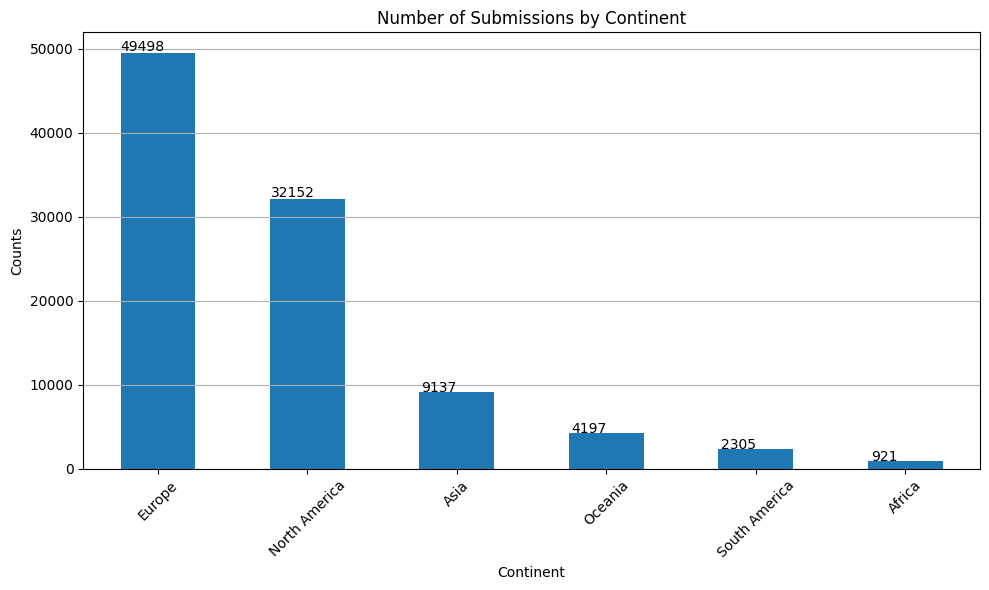

In [55]:
# Plot the bar chart
ax = df2["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [56]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    143.000000
mean      -0.262087
std        0.996337
min       -2.461897
25%       -0.918060
50%       -0.311190
75%        0.447168
max        2.618827
Name: log_num_entries_per_lakh, dtype: float64

In [57]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    143.000000
mean       2.199810
std        0.996337
min        0.000000
25%        1.543837
50%        2.150707
75%        2.909065
max        5.080723
Name: log_num_entries_per_lakh, dtype: float64

In [61]:
plots_path = "epicov2020_plots/1Jan20_15Apr20_collection/"

In [62]:
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]


fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title='Submissions per Lakh Population (World) | Log 10 Scale',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            'population_2020': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(plots_path + "choropleth_entries_per_lakh_log10_continents.html"))
fig.show()

Plot per‐continent maps

In [65]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title='Submissions per 1 Lakh Population by Continent | Log 10 Scale',
                           label='Submissions/Lakh (Log 10)',
                           )
fig.write_html(os.path.join(plots_path + "choropleth_entries_per_lakh_log10_continents.html"))
fig.show()

#### A.2. Gender distribution across countries

Let's next look at the gender distribution across countries again grouped by continents

In [67]:
df_merged["gender_m_per_lakh"], df_merged["gender_f_per_lakh"], df_merged["gender_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "gender_m_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Male")].shape[0])/(row["population_2020"] / 1e5)
        df_merged.loc[i, "gender_f_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Female")].shape[0])/(row["population_2020"] / 1e5)
        df_merged.loc[i, "gender_u_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "unknown")].shape[0])/(row["population_2020"] / 1e5)

In [68]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          232 non-null    object 
 1   continent                        232 non-null    object 
 2   population_2020                  232 non-null    int64  
 3   country_standard                 232 non-null    object 
 4   num_entries                      143 non-null    float64
 5   num_entries_per_lakh             143 non-null    float64
 6   log_num_entries_per_lakh         143 non-null    float64
 7   log_num_entries_per_lakh_filled  232 non-null    float64
 8   gender_m_per_lakh                143 non-null    float64
 9   gender_f_per_lakh                143 non-null    float64
 10  gender_u_per_lakh                143 non-null    float64
dtypes: float64(7), int64(1), object(3)
memory usage: 20.1+ KB


In [69]:
df_merged["log_gender_m_per_lakh"] = np.log10(df_merged["gender_m_per_lakh"].replace(0, np.nan))
df_merged["log_gender_m_per_lakh"].describe()

count    124.000000
mean      -0.667962
std        0.942867
min       -3.070041
25%       -1.243563
50%       -0.798481
75%       -0.066419
max        2.319503
Name: log_gender_m_per_lakh, dtype: float64

In [71]:
sign = -1 if df_merged["log_gender_m_per_lakh"].min() < 0 else 1
df_merged["log_gender_m_per_lakh"] = df_merged["log_gender_m_per_lakh"] + (df_merged["log_gender_m_per_lakh"].min() * sign)
df_merged["log_gender_m_per_lakh"].describe()

count    124.000000
mean       2.402079
std        0.942867
min        0.000000
25%        1.826478
50%        2.271560
75%        3.003622
max        5.389544
Name: log_gender_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each gender. First we look at a zoomed out view of the whole world

In [77]:
# World map - distribution of males
# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.05, "#9ecae1"],
    [0.1, "#6bb8d6"],
    [0.2, "#3182bd"],
    [0.4, "#08519c"],
    [1.0, "#08306b"]   # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_gender_m_per_lakh",
                       color_scale=male_scale,
                       title="Number of submissions from Males per Lakh Population (World)",
                       label="Males/1M",
                       hover_data={
                            'gender_m_per_lakh': True,
                            'population_2020': True,
                            'country': False
                        })

fig.write_html(os.path.join(plots_path + "choropleth_males_per_lakh_log10_world.html"))
fig.show()

In [78]:
df_merged["log_gender_f_per_lakh"] = np.log10(df_merged["gender_f_per_lakh"].replace(0, np.nan))
df_merged["log_gender_f_per_lakh"].describe()

count    115.000000
mean      -0.705667
std        0.960215
min       -2.737650
25%       -1.340397
50%       -0.847791
75%       -0.099325
max        2.313213
Name: log_gender_f_per_lakh, dtype: float64

In [79]:
sign = -1 if df_merged["log_gender_f_per_lakh"].min() < 0 else 1
df_merged["log_gender_f_per_lakh"] = df_merged["log_gender_f_per_lakh"] + (df_merged["log_gender_f_per_lakh"].min() * sign)
df_merged["log_gender_f_per_lakh"].describe()

count    115.000000
mean       2.031983
std        0.960215
min        0.000000
25%        1.397253
50%        1.889859
75%        2.638325
max        5.050863
Name: log_gender_f_per_lakh, dtype: float64

In [82]:
# World map - distribution of females
# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_f_per_lakh",
                       color_scale=female_scale,
                       title="Number of submissions from Females per Lakh Population (World)",
                       label="Females/1M",
                       hover_data={
                            'gender_f_per_lakh': True,
                            'population_2020': True,
                            'country': False
                        })

fig.write_html(os.path.join(plots_path + "choropleth_females_per_lakh_log10_world.html"))
fig.show()

In [ ]:
# World map - distribution of females
# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],     # very light tan
    [0.003, "#fdd49e"],     # light tan-orange
    [0.005, "#fdbb84"],     # medium golden tan
    [0.007, "#e08214"],     # golden brown
    [1.0, "#8c510a"]      # dark brown
]

fig = choropleth_world(df_merged,
                       value_column="gender_u_per_m",
                       color_scale=unknown_scale,
                       title="Number of Unknown gender per Million Population (World)",
                       label="Missing gender/1M",
                       hover_data={
                            'gender_u_per_m': True,
                            'population': True,
                            'country': False
                        })

fig.show()
fig.write_html("epicov2020_plots/choropleth_unknown_gender_per_m_world.html")

In [ ]:
cont_av_u = [(a,df_merged[(df_merged["continent"]==a)&(df_merged["gender_u_per_m_filled"] >= 0)]["gender_u_per_m"].mean()) for a in df_merged["continent"].unique()]
asc = sorted(cont_av_u, key=lambda x: x[1])
df_u = df_merged[df_merged["gender_u_per_m_filled"] >= 0].sort_values(by=["gender_u_per_m_filled"], ascending=True)
asc

In [ ]:
df_p = df_merged[["country_standard","continent"]].drop_duplicates().dropna()
df_p["continent"].value_counts()

In [ ]:
df_u[df_u["gender_u_per_m_filled"]==0.0]["continent"].value_counts()

In [ ]:
df_u[df_u["gender_u_per_m_filled"]==0.0]

In [ ]:
df_u.tail(10)

Now we plot the continent-wise choropleth maps

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='gender_m_per_m',
                           color_scale=male_scale,
                           title="Number of Males per Million Population by Continent",
                           label="Males/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_males_per_m_continents.html")

Let's try log scale here too

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='log_males_per_m_adjusted',
                           color_scale=male_scale1,
                           title="Number of Males per Million Population by Continent | log scale",
                           label="Males/1M",
                           )

fig.show()

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='gender_f_per_m',
                           color_scale=female_scale,
                           title="Number of Females per Million Population by Continent",
                           label="Females/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_females_per_m_continents.html")

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='gender_u_per_m',
                           color_scale=unknown_scale,
                           title="Number of Missing gender per Million Population by Continent",
                           label="Missing gender/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_unknown_gender_per_m_continents.html")

Let's see how the gender ratio is across continents and countries

In [ ]:
df_merged["male_female_ratio"] = df_merged["gender_m_per_m"] / df_merged["gender_f_per_m"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

In [ ]:
custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#053061"], # Deep blue
    [0.1, "#2166ac"],    # Blue
    [0.33, "#f7f7f7"],     # White (neutral)
    [0.66, "#b2182b"],    # Red
    [1.0, "#67001f"]      # Deep red
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title="Male to Female ratio (World)",
                       label="Gender ratio",
                       hover_data={
                            'male_female_ratio': True,
                            'population': True,
                            'country': False
                        })

fig.show()

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Gender ratio by Continent",
                           label="Gender ratio",
                            hover_data={"male_female_ratio": True,
                                        "population": True,
                                        "country": False}
                           )

fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [ ]:
list(df2["Patient status"].unique())

As we see there are a lot of overlapping categories. Let us group them together into meaningful categories as follows

In [ ]:
status_mapping = {
    'unknown': 'Unknown/Missing',
    'Epidemiology Study': 'Unknown/Missing',
    'Screening': 'Unknown/Missing',
    np.nan: 'Unknown/Missing',

    'Asymptomatic': 'Mild/Recovering',
    'Mild': 'Mild/Recovering',
    'Mild symptoms (fever, cardiovascular disorders)': 'Mild/Recovering',
    'Recovering': 'Mild/Recovering',
    'Recovered': 'Mild/Recovering',
    'Stable in quarantine': 'Mild/Recovering',

    'Hospitalized (Mild)': 'Hospitalized - Mild/Stable',
    'Hospitalized (Stable)': 'Hospitalized - Mild/Stable',
    'Pneumonia (chest X-ray), not critical': 'Hospitalized - Mild/Stable',
    'Pneumonia (chest X-ray)': 'Hospitalized - Mild/Stable',

    'ICU; Serious': 'Hospitalized - Intensive/Critical',
    'Intensive Care Unit': 'Hospitalized - Intensive/Critical',
    'Hospitalized (Intensive care unit)': 'Hospitalized - Intensive/Critical',

    'Deceased': 'Deceased',

    'Discharged': 'Discharged/Released',
    'Released': 'Discharged/Released',
    'Live': 'Discharged/Released',
    'Initially hospitalized, but now improved and discharged': 'Discharged/Released',

    'Hospitalized': 'Hospitalized (General)',

    'EHPAD': 'Nursing Home',

    'Symptomatic': 'Symptomatic (Unspecified)'
}

severity_level = {
    'Mild/Recovering': 'Least Severe',
    'Discharged/Released': 'Least Severe',
    
    'Symptomatic (Unspecified)': 'Mild',
    'Hospitalized - Mild/Stable': 'Mild',
    'Hospitalized (General)': 'Mild',
    'Nursing Home': 'Mild',
    
    'Hospitalized - Intensive/Critical': 'Severe',
    'Deceased': 'Severe',
    
    'Unknown/Missing': 'Unknown'
}

Now we apply this mapping to the dataframe

In [ ]:
df2['status_category'] = df2['Patient status'].map(status_mapping)
df2['status_category'].value_counts()

In [ ]:
df2["severity_level"] = df2["status_category"].map(severity_level)
df2["severity_level"].value_counts()

In [ ]:
df_merged["status_l_per_m"], df_merged["status_m_per_m"], df_merged["status_s_per_m"], df_merged["status_u_per_m"] = float('nan'), float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "status_l_per_m"] = (df2[(df2["country"] == country) & (df2["severity_level"] == "Least Severe")].shape[0])/(row["population"] / 1e6)
        df_merged.loc[i, "status_m_per_m"] = (df2[(df2["country"] == country) & (df2["severity_level"] == "Mild")].shape[0])/(row["population"] / 1e6)
        df_merged.loc[i, "status_s_per_m"] = (df2[(df2["country"] == country) & (df2["severity_level"] == "Severe")].shape[0])/(row["population"] / 1e6)
        df_merged.loc[i, "status_u_per_m"] = (df2[(df2["country"] == country) & (df2["severity_level"] == "Unknown")].shape[0])/(row["population"] / 1e6)
df_merged.info()

For choropleth maps, its better to have 4 different maps one for each severity level. First we look at a zoomed out view of the whole world

In [ ]:
# World map - distribution of least severe cases
# Define custom color scale including a gray value for the sentinel
least_severe_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#f7fcf5"], # very pale green
    [0.01, "#e5f5e0"],  # very light green
    [0.03, "#c7e9c0"],  # light green
    [0.1, "#a1d99b"],  # medium light green
    [0.5, "#41ab5d"],  # strong green
    [1.0, "#006837"]     # dark forest green
]

fig = choropleth_world(df_merged,
                       value_column="status_l_per_m",
                       color_scale=least_severe_scale,
                       title="Number of least severe cases per Million Population (World)",
                       label="least severe/1M",
                       hover_data={
                            'status_l_per_m': True,
                            'population': True,
                            'country': False
                        })

fig.show()
fig.write_html("epicov2020_plots/choropleth_least_severe_per_m_world.html")

In [ ]:
cont_av_l = [(a,df_merged[(df_merged["continent"]==a)&(df_merged["status_l_per_m_filled"] >= 0)]["status_l_per_m"].mean()) for a in df_merged["continent"].unique()]
asc = sorted(cont_av_l, key=lambda x: x[1])
df_l = df_merged[df_merged["status_l_per_m_filled"] >= 0].sort_values(by=["status_l_per_m_filled"], ascending=True)
asc

In [ ]:
df_l[df_l["status_l_per_m_filled"]==0.0].shape

In [ ]:
df_l.tail(10)

In [ ]:
# World map - distribution of mildly severe cases
# Define custom color scale including a gray value for the sentinel
mild_severe_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#fff5eb"], # very pale orange
    [0.001, "#fee6ce"],  # very light orange
    [0.003, "#fdd0a2"],  # light orange
    [0.005, "#fdae6b"],  # medium orange
    [0.007, "#e6550d"],  # deep orange
    [1.0, "#a63603"]     # dark burnt orange
]


fig = choropleth_world(df_merged,
                       value_column="status_m_per_m",
                       color_scale=mild_severe_scale,
                       title="Number of mildly severe cases per Million Population (World)",
                       label="mildly severe/1M",
                       hover_data={
                            'status_m_per_m': True,
                            'population': True,
                            'country': False
                        })

fig.show()
fig.write_html("epicov2020_plots/choropleth_mildly_severe_per_m_world.html")

In [ ]:
cont_av_m = [(a,df_merged[(df_merged["continent"]==a)&(df_merged["status_m_per_m_filled"] >= 0)]["status_m_per_m"].mean()) for a in df_merged["continent"].unique()]
asc = sorted(cont_av_m, key=lambda x: x[1])
df_m = df_merged[df_merged["status_m_per_m_filled"] >= 0].sort_values(by=["status_m_per_m_filled"], ascending=True)
asc

In [ ]:
df_m[df_m["status_m_per_m_filled"]==0.0]["continent"].value_counts()

In [ ]:
df_m[df_m["status_m_per_m_filled"]==0.0].shape

In [ ]:
df_m.tail()

In [ ]:
# World map - distribution of very severe cases
# Define custom color scale including a gray value for the sentinel
very_severe_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#fff5f0"], # very pale red
    [0.001, "#fee0d2"],  # very light red
    [0.1, "#fcbba1"],  # light red
    [0.3, "#ffa488"],  # medium red
    [0.5, "#fe544e"],  # deep red
    [1.0, "#a50f15"]     # dark crimson red
]


fig = choropleth_world(df_merged,
                       value_column="status_s_per_m",
                       color_scale=very_severe_scale,
                       title="Number of very severe cases per Million Population (World)",
                       label="very severe/1M",
                       hover_data={
                            'status_s_per_m': True,
                            'population': True,
                            'country': False
                        })

fig.show()
fig.write_html("epicov2020_plots/choropleth_very_severe_per_m_world.html")

In [ ]:
cont_av_s = [(a,df_merged[(df_merged["continent"]==a)&(df_merged["status_s_per_m_filled"] >= 0)]["status_s_per_m"].mean()) for a in df_merged["continent"].unique()]
asc = sorted(cont_av_s, key=lambda x: x[1])
df_s = df_merged[df_merged["status_s_per_m_filled"] >= 0].sort_values(by=["status_s_per_m_filled"], ascending=True)
asc

In [ ]:
df_s[df_s["status_s_per_m_filled"]==0.0]["continent"].value_counts()

In [ ]:
df_s[df_s["status_s_per_m_filled"]==0.0].shape

In [ ]:
df_s.tail(10)

In [ ]:
# World map - distribution of unknown status
# Define custom color scale including a gray value for the sentinel
unknown_status_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#e5daec"],  # pale lavender
    [0.001, "#d4c4e1"],  # light plum
    [0.003, "#c2a5cf"],  # base muted plum
    [0.005, "#a583b3"],  # medium plum
    [0.007, "#865a99"],  # deep plum
    [1.0, "#6b3c7d"]     # dark purple-plum
]


fig = choropleth_world(df_merged,
                       value_column="status_u_per_m",
                       color_scale=unknown_status_scale,
                       title="Number of unknown status cases per Million Population (World)",
                       label="unknown status/1M",
                       hover_data={
                            'status_u_per_m': True,
                            'population': True,
                            'country': False
                        })

fig.show()
fig.write_html("epicov2020_plots/choropleth_unknown_status_per_m_world.html")

In [ ]:
cont_av_u = [(a,df_merged[(df_merged["continent"]==a)&(df_merged["status_u_per_m_filled"] >= 0)]["status_u_per_m"].mean()) for a in df_merged["continent"].unique()]
asc = sorted(cont_av_u, key=lambda x: x[1])
df_u = df_merged[df_merged["status_u_per_m_filled"] >= 0].sort_values(by=["status_u_per_m_filled"], ascending=True)
asc

In [ ]:
df_u[df_u["status_u_per_m_filled"]==0.0]["continent"].value_counts()

In [ ]:
df_u.head(15)

In [ ]:
df_u.tail(10)

Now, let's look at each continent

fig = choropleth_continent(df_merged,
                           value_column='status_l_per_m',
                           color_scale=least_severe_scale,
                           title="Number of least severe cases per Million Population by Continent",
                           label="least severe/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_least_severe_per_m_continents.html")

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='status_m_per_m',
                           color_scale=mild_severe_scale,
                           title="Number of mild severe cases per Million Population by Continent",
                           label="mild severe/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_mild_severe_per_m_continents.html")

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='status_s_per_m',
                           color_scale=very_severe_scale,
                           title="Number of very severe cases per Million Population by Continent",
                           label="very severe/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_very_severe_per_m_continents.html")

In [ ]:
fig = choropleth_continent(df_merged,
                           value_column='status_u_per_m',
                           color_scale=unknown_status_scale,
                           title="Number of unknown status cases per Million Population by Continent",
                           label="unknown status/1M",
                           )

fig.show()
fig.write_html("epicov2020_plots/choropleth_unknown_status_per_m_continents.html")

In [ ]:
df2["severity_level"].value_counts()

In [ ]:
status_to_num_mapping = {"Least Severe": 1, 
                         "Mild": 2, 
                         "Severe": 3, 
                         "Unknown": np.nan}

df2["severity_num"] = df2["severity_level"].map(status_to_num_mapping)
df_merged["avg_status_per_tm"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "avg_status_per_tm"] = (df2[df2["country"] == country]["severity_num"].mean()) / (row["population"] / 1e7)

df_merged["avg_status_per_tm"].describe()

In [ ]:
"Turkey" in df_merged["country"].values, "Turkey" in df_merged["country_standard"].values

In [ ]:
sorted(df_merged["country_standard"].unique().tolist())

In [ ]:
custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="avg_status_per_tm",
                       color_scale=custom_scale,
                       title="Health status (World)",
                       label="Avg severity/10M",
                       hover_data={
                            'status_u_per_m': True,
                            'avg_status_per_tm': True,
                            'population': True,
                            'country': False
                        })

fig.show()

### A.3. Age distribution

Let's see what is the age distribution of the patients across each geographical location

In [ ]:
df2["Patient age"].unique()

The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [ ]:
import re

def map_age_to_group(age):
    try:
        # Clean input
        if pd.isna(age) or age == 'unknown':
            return 'unknown'
        
        # Convert ranges to approximate midpoints (e.g., "50-54" -> 52)
        if '-' in age:
            parts = age.split('-')
            if all(part.isdigit() for part in parts): # check if both parts are numbers
                age = str((int(parts[0]) + int(parts[1])) // 2)
        
        # Convert strings like ">70", ">50" to numeric estimates
        if '>' in age:
            num = re.findall(r'\d+', age)
            if num:
                age = int(num[0]) + 1  # assume ">70" means at least 71
            else:
                return 'unknown'  # if no number found, return unknown
        
        # Convert fractional or float values
        if isinstance(age, str) and re.fullmatch(r'\d+(\.\d+)?', age):
            age = float(age)
        
        # Handle months/days
        if isinstance(age, str) and any(unit in age for unit in ['month', 'day']):
            return '<5'
        
        # Final conversion to float
        age = float(age)
        
        # Assign GBD group
        if age < 5:
            return '<5'
        elif 5 <= age <= 14:
            return '5-14'
        elif 15 <= age <= 49:
            return '15-49'
        elif 50 <= age <= 69:
            return '50-69'
        elif age >= 70:
            return '>70'
        else:
            return 'unknown'
    except:
        return 'unknown'

In [ ]:
df2['age_group'] = df2['Patient age'].apply(map_age_to_group)

In [ ]:
# Plot the bar chart
ax = df2["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Value Counts of Entries')
plt.show()

In [ ]:
df2.columns

In [ ]:
df2[df2["Collection date"] < "2020-01-01"].shape

In [ ]:
df2[df2["Collection date"] < "2020-01-01"].sort_values(by=["Collection date"])

In [ ]:
df2.columns

In [ ]:
df2["Gender"].value_counts()

In [ ]:
df2["status_category"].value_counts()

In [ ]:
df2["status_category"].unique()